# 06: Course2Vec - Learning Course Embeddings from Co-Enrollment Patterns

Can we learn useful representations of university courses from enrollment data alone?
The idea comes from Word2Vec: treat each student's enrollment history as a sentence and
each course as a word. Courses that students consistently take together should end up
with similar vectors, even without any explicit information about prerequisites or content.

This notebook trains a Skip-gram Word2Vec model on enrollment sequences.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from gensim.models import Word2Vec
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

from educast.config import (
    NUM_COURSES, FEAT_DIM_STUDENT, MICRO_WINDOW_SIZE, SPLIT_YEAR, RANDOM_SEED,
    SUBJECTS_Q1, SUBJECTS_Q2, SUBJECTS_Q3, SUBJECTS_Q4,
    SUBJECTS_Q5, SUBJECTS_Q6, SUBJECTS_Q7, SUBJECTS_TFG, SUBJECTS_OPTIONAL,
)
from educast.data.loader import (
    load_university_json, build_course_vocabulary, build_course_label_map,
    build_acronym_maps,
)
from educast.features.multihot import build_student_dataset
from educast.data.splits import split_by_year
from educast.data.transforms import create_macro_dataset
from educast.evaluation.metrics import compute_mae, per_course_mae
from educast.evaluation.export import export_results, build_experiment_metadata
from educast.models.naive import NaiveModel

## 1. Load Data

In [2]:
university_data = load_university_json()
course_ids, course_to_idx, idx_to_course = build_course_vocabulary(university_data)
labels = build_course_label_map(university_data, idx_to_course)
students = university_data["students"]

print(f"Students: {len(students)}, Courses: {len(course_ids)}")

Students: 505, Courses: 51


## 2. Build Enrollment Sentences

To apply Word2Vec we present the enrollment data as sequences of tokens to generate sentences of words. We construct two complementary sentence types from each student's record.

The first type groups all courses a student takes in the same semester into a single sentence. This captures the co-enrollment signal: if two courses consistently appear together in the same term, the model learns to place them nearby in embedding space. The second type concatenates a student's entire course history in chronological order into one long sentence, capturing the temporal and prerequisite signal: courses taken in consecutive semesters share a context window, so the model learns that, say, Teoria de Circuits typically follows Física.

Both sentence types are combined for training. Sentences with fewer than two courses are discarded because a single-token sentence provides no context for the Skip-gram objective to learn from.

In [3]:
# Build "sentences" -- each student's per-semester enrollment becomes a sentence of course IDs
semester_sentences = []  # List of lists of course_id strings
history_sentences = []   # Full student history as one sentence

for student in students:
    attempts = student.get("history", {}).get("attempts", [])
    if not attempts:
        continue

    # Group by (year, term)
    by_term = defaultdict(list)
    for att in attempts:
        year, term = att.get("year"), att.get("term")
        if year and term:
            cid = att["course"]["course_id"]
            by_term[(year, term)].append(cid)

    # Per-semester sentences (co-enrollment context)
    for (year, term), courses in sorted(by_term.items()):
        if len(courses) >= 2:  # Need at least 2 courses for context
            semester_sentences.append(courses)

    # Full student history (temporal context)
    full = []
    for (year, term), courses in sorted(by_term.items()):
        full.extend(courses)
    if len(full) >= 2:
        history_sentences.append(full)

all_sentences = semester_sentences + history_sentences
print(f"Semester sentences: {len(semester_sentences)}")
print(f"History sentences: {len(history_sentences)}")
print(f"Total sentences: {len(all_sentences)}")
print(f"Example semester sentence: {semester_sentences[0][:8]}")

Semester sentences: 2537
History sentences: 505
Total sentences: 3042
Example semester sentence: ['330212', '330213', '330214', '330215', '330216']


## 3. Train Course2Vec

The embedding dimension is set to 16. With a vocabulary of just 51 courses, higher dimensions risk overfitting: the model would have enough capacity to memorize co-occurrence patterns rather than learning generalizable structure. A context window of 5 lets the model see roughly one semester's worth of neighbouring courses on each side, which is enouggh given that EPSEM students typically enroll in 4 to 6 courses per term.

In [ ]:
np.random.seed(RANDOM_SEED)

c2v_model = Word2Vec(
    sentences=all_sentences,
    vector_size=16,        # embedding dimension
    window=5,              # context window
    min_count=2,           # minimum course frequency
    sg=1,                  # skip-gram (1) vs CBOW (0)
    epochs=50,
    seed=RANDOM_SEED,
    workers=1,             # deterministic
)

print(f"Vocabulary size: {len(c2v_model.wv)}")
print(f"Embedding dim: {c2v_model.wv.vector_size}")

# Build embedding matrix aligned with course_to_idx
EMBEDDING_DIM = c2v_model.wv.vector_size
embedding_matrix = np.zeros((NUM_COURSES, EMBEDDING_DIM))
covered = 0
for cid, idx in course_to_idx.items():
    if cid in c2v_model.wv:
        embedding_matrix[idx] = c2v_model.wv[cid]
        covered += 1

print(f"Courses with embeddings: {covered}/{NUM_COURSES}")

## 4. Analysis

The 16-dimensional embeddings are projected to 2D with t-SNE (van der Maaten & Hinton, 2008).
t-SNE preserves local neighbourhood structure.

Perplexity=15 here controls the effective number of neighbours per point. With 49 courses,
this is around a 1/3 of the dataset which is reasonable. 

Each course is coloured by its semester in the EPSEM TIC curriculum (Q1–Q7,
plus TFG and optional courses). If the embeddings are meaningful, same-semester courses
should cluster together, since students normally co-enroll within a curricular year.

In [ ]:
course_indices = []
course_labels_list = []
course_vectors = []

for cid, idx in course_to_idx.items():
    if cid in c2v_model.wv:
        course_indices.append(idx)
        course_labels_list.append(labels.get(idx, cid))
        course_vectors.append(c2v_model.wv[cid])

vectors = np.array(course_vectors)

# t-SNE projection
tsne = TSNE(n_components=2, random_state=RANDOM_SEED, perplexity=min(15, len(vectors) - 1))
coords = tsne.fit_transform(vectors)

# Build course_id -> acronym map for semester colour coding
id_to_acr, _, _ = build_acronym_maps(university_data)

semester_groups = {
    "Q1": SUBJECTS_Q1, "Q2": SUBJECTS_Q2, "Q3": SUBJECTS_Q3, "Q4": SUBJECTS_Q4,
    "Q5": SUBJECTS_Q5, "Q6": SUBJECTS_Q6, "Q7": SUBJECTS_Q7,
    "TFG": SUBJECTS_TFG, "Optional": SUBJECTS_OPTIONAL,
}


def get_semester_label(course_id: str) -> str:
    """Map a course_id to its canonical semester label."""
    acr = id_to_acr.get(course_id, "")
    for sem, subjects in semester_groups.items():
        if acr in subjects:
            return sem
    return "Other"


colors_map = {
    "Q1": "#e41a1c", "Q2": "#377eb8", "Q3": "#4daf4a", "Q4": "#984ea3",
    "Q5": "#ff7f00", "Q6": "#a65628", "Q7": "#f781bf", "TFG": "#999999",
    "Optional": "#66c2a5", "Other": "#cccccc",
}

plt.figure(figsize=(12, 10))
for i, (ci, label) in enumerate(zip(course_indices, course_labels_list)):
    cid = idx_to_course[ci]
    sem = get_semester_label(cid)
    color = colors_map.get(sem, "#cccccc")
    plt.scatter(coords[i, 0], coords[i, 1], c=color, s=100,
                edgecolors="black", linewidths=0.5, zorder=2)
    plt.annotate(label[:20], (coords[i, 0], coords[i, 1]),
                 fontsize=7, ha="center", va="bottom")

# Legend
for sem, color in colors_map.items():
    plt.scatter([], [], c=color, s=80, edgecolors="black", linewidths=0.5, label=sem)
plt.legend(title="Semester", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.title("Course2Vec Embedding Space (t-SNE)", fontsize=14)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

## 5. Nearest-Neighbour Courses

For each course we find the three nearest neighbours by cosine similarity. If the embeddings have captured curriculum structure, we would expect to see courses from the same semester as neighbours. Courses that share student populations, for instance optional courses chosen by the same subgroup of students, should also appear similar even if they belong to different semesters.

In [ ]:
sim_matrix = cosine_similarity(embedding_matrix)

print("=" * 90)
print("TOP-3 MOST SIMILAR COURSES (by embedding cosine similarity)")
print("=" * 90)

rows = []
for idx in range(NUM_COURSES):
    cid = idx_to_course[idx]
    if cid not in c2v_model.wv:
        continue

    sims = sim_matrix[idx].copy()
    sims[idx] = -1  # exclude self

    top3_idx = np.argsort(sims)[-3:][::-1]
    name = labels.get(idx, cid)
    neighbors = []
    for ni in top3_idx:
        nname = labels.get(ni, idx_to_course[ni])
        neighbors.append(f"{nname[:25]} ({sims[ni]:.3f})")

    rows.append({
        "Course": name[:30],
        "Top-1": neighbors[0] if len(neighbors) > 0 else "",
        "Top-2": neighbors[1] if len(neighbors) > 1 else "",
        "Top-3": neighbors[2] if len(neighbors) > 2 else "",
    })

df_neighbors = pd.DataFrame(rows)
print(df_neighbors.to_string(index=False))

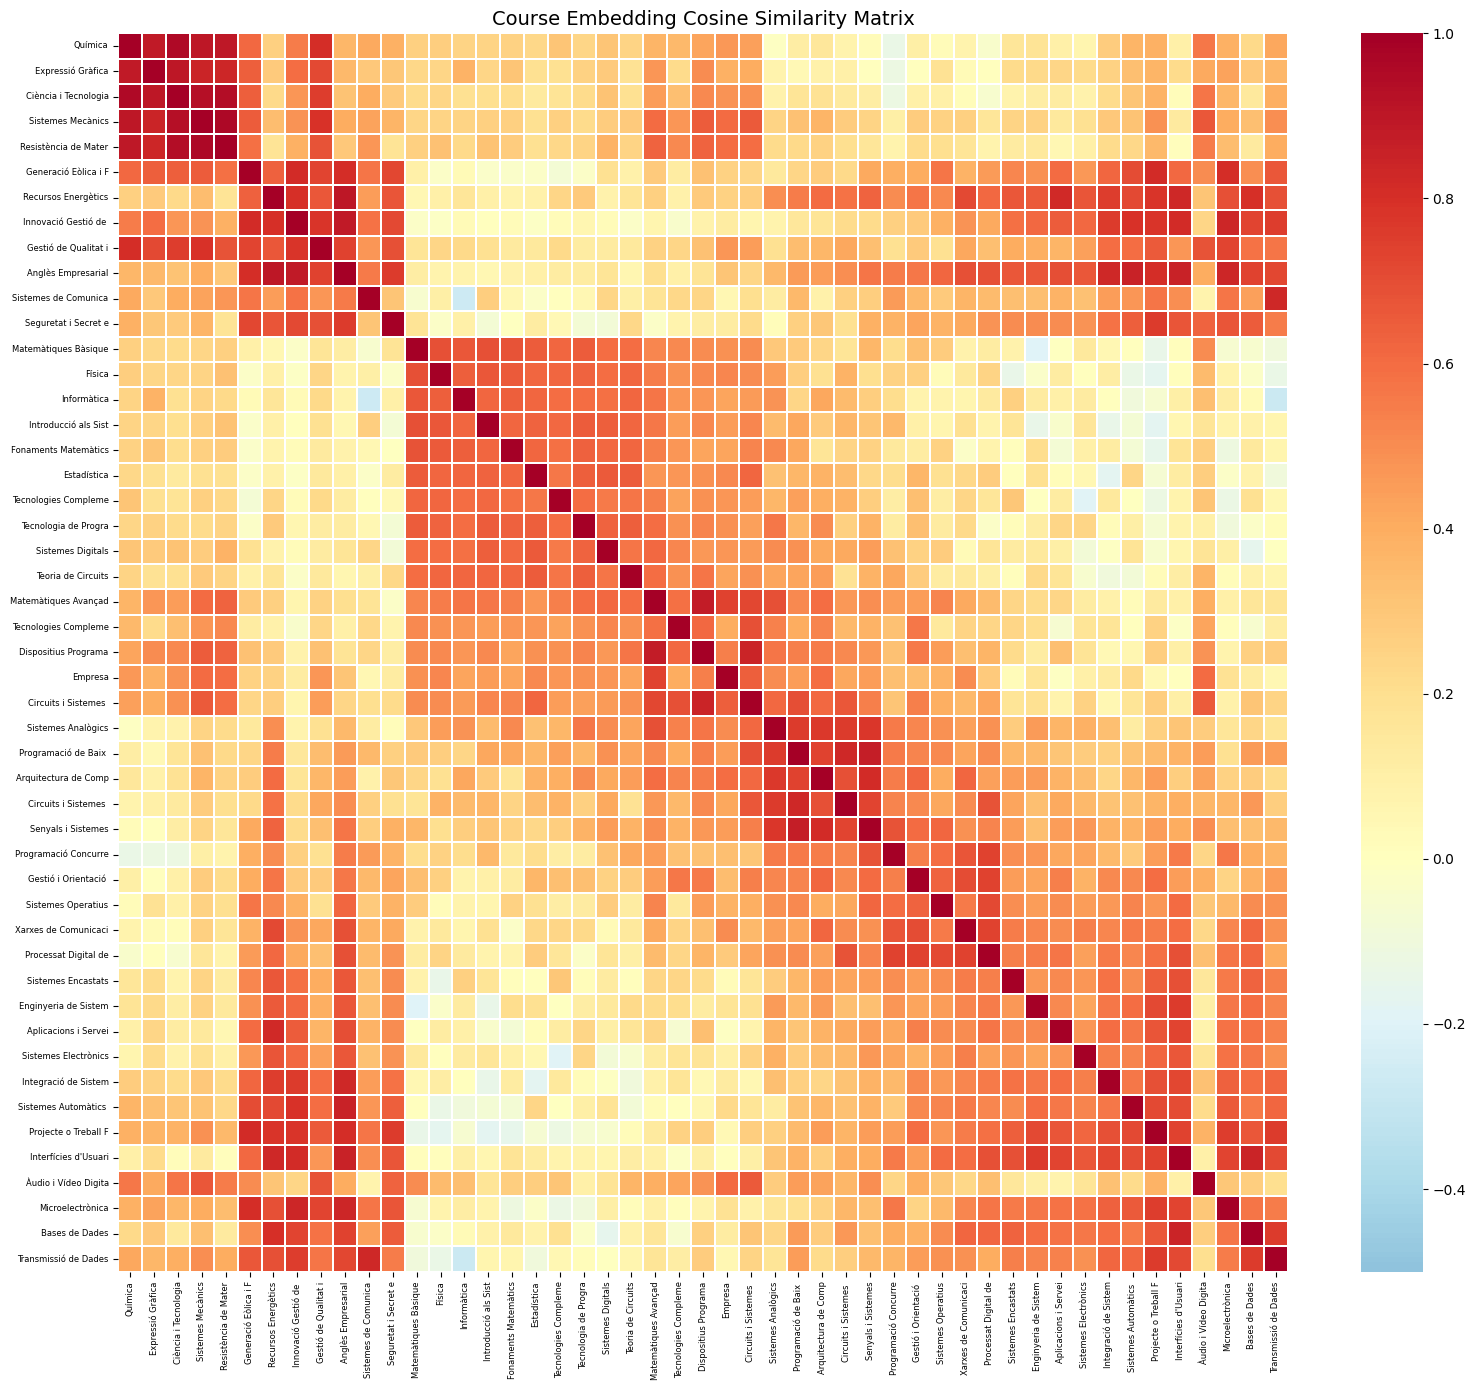

In [7]:
# Similarity heatmap for all courses with embeddings
active_indices = [i for i in range(NUM_COURSES) if idx_to_course[i] in c2v_model.wv]
active_labels = [labels.get(i, idx_to_course[i])[:20] for i in active_indices]
sub_matrix = sim_matrix[np.ix_(active_indices, active_indices)]

plt.figure(figsize=(16, 14))
sns.heatmap(
    sub_matrix, xticklabels=active_labels, yticklabels=active_labels,
    cmap="RdYlBu_r", center=0, vmin=-0.5, vmax=1.0,
    linewidths=0.1, linecolor="white",
)
plt.title("Course Embedding Cosine Similarity Matrix", fontsize=14)
plt.xticks(fontsize=6, rotation=90)
plt.yticks(fontsize=6)
plt.tight_layout()
plt.show()

## 6. Embedding-Enhanced Features

Raw student features (enrollment flags, grades, attempt counts) tell us what a student did
but not where they sit in the curriculum. A Q1 student and a Q5 student with similar
enrollment counts look identical in the raw feature space.

In [ ]:
X_all, y_all, meta_all = build_student_dataset(
    university_data, course_to_idx, window_size=MICRO_WINDOW_SIZE
)

print(f"Student dataset: X={X_all.shape}, y={y_all.shape}")


def compute_embedding_features(X_window: np.ndarray, emb_matrix: np.ndarray) -> np.ndarray:
    """Compute embedding-based features for a single student window.

    For each time step in the window:
    - Mean embedding of enrolled courses (16-dim)
    - Grade-weighted mean embedding (16-dim)

    Plus trajectory features:
    - Embedding difference between last two steps (16-dim)

    Total: window_size * 32 + 16 dims
    """
    window_size = X_window.shape[0]
    emb_dim = emb_matrix.shape[1]
    features = []

    prev_mean = np.zeros(emb_dim)
    for t in range(window_size):
        enrollment = X_window[t, :NUM_COURSES]
        grades = X_window[t, NUM_COURSES:NUM_COURSES * 2]

        enrolled_idx = np.where(enrollment > 0)[0]

        if len(enrolled_idx) > 0:
            # Mean embedding of enrolled courses
            mean_emb = emb_matrix[enrolled_idx].mean(axis=0)

            # Grade-weighted mean (use grade if available, else 0.5)
            weights = np.array([
                grades[i] if grades[i] >= 0 else 0.5
                for i in enrolled_idx
            ])
            if weights.sum() > 0:
                weighted_emb = np.average(emb_matrix[enrolled_idx], axis=0, weights=weights)
            else:
                weighted_emb = mean_emb.copy()
        else:
            mean_emb = np.zeros(emb_dim)
            weighted_emb = np.zeros(emb_dim)

        features.extend(mean_emb)
        features.extend(weighted_emb)

        if t == window_size - 1:
            # Trajectory: difference from previous step
            features.extend(mean_emb - prev_mean)
        prev_mean = mean_emb.copy()

    return np.array(features)


emb_features = np.array([
    compute_embedding_features(X_all[i], embedding_matrix)
    for i in range(len(X_all))
])

print(f"Embedding features shape: {emb_features.shape}")

# Flatten original features: (N, 3, 154) -> (N, 462)
X_flat = X_all.reshape(len(X_all), -1)

# Concatenate: original (462) + embedding features (112) = 574
X_enhanced = np.concatenate([X_flat, emb_features], axis=1)
print(f"Original flattened: {X_flat.shape}")
print(f"Enhanced features: {X_enhanced.shape}")

## 7. Train MLP with Embedding Features

We train a two-layer network with 128 and 64 hidden units, ReLU activations, and dropout, with just a difference in their input. The baseline MLP receives the original 462-dimensional flattened features, while the Course2Vec MLP receives the 574-dimensional enhanced features. Both use binary cross-entropy loss, treating each of the 51 courses as an independent binary prediction.

The architecture is quite simple. The goal here is not to build the best possible predictor (the Micro LSTM already handles temporality more naturally), but to determine whether the embedding features carry information that the raw features do not. Any performance gap between two identical architectures that differ only in the presence of embedding features can be linked to those features.

In [ ]:
X_train, y_train, meta_train, X_test, y_test, meta_test = split_by_year(
    X_enhanced, y_all, meta_all, split_year=SPLIT_YEAR
)

X_train_orig, _, _, X_test_orig, _, _ = split_by_year(
    X_flat, y_all, meta_all, split_year=SPLIT_YEAR
)

print(f"Train: {len(X_train)} samples")
print(f"Test:  {len(X_test)} samples")
print(f"Enhanced feature dim: {X_train.shape[1]}")
print(f"Baseline feature dim: {X_train_orig.shape[1]}")


class EnrollmentMLP(nn.Module):
    """Simple 2-layer MLP for per-course enrollment prediction."""

    def __init__(self, input_dim: int, hidden_dim: int = 128, output_dim: int = NUM_COURSES):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(hidden_dim // 2, output_dim),
            nn.Sigmoid(),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


def train_mlp(
    X_train: np.ndarray,
    y_train: np.ndarray,
    input_dim: int,
    epochs: int = 100,
    batch_size: int = 64,
    lr: float = 0.001,
    seed: int = RANDOM_SEED,
) -> tuple:
    """Train an EnrollmentMLP and return the model + loss history."""
    torch.manual_seed(seed)
    np.random.seed(seed)

    X_t = torch.FloatTensor(X_train)
    y_t = torch.FloatTensor(y_train)

    dataset = TensorDataset(X_t, y_t)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model = EnrollmentMLP(input_dim)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()

    history = {"train_loss": []}
    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for xb, yb in loader:
            pred = model(xb)
            loss = criterion(pred, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        history["train_loss"].append(epoch_loss / len(loader))

    return model, history


print("Training MLP with embedding-enhanced features...")
model_enhanced, hist_enhanced = train_mlp(X_train, y_train, X_train.shape[1])
print(f"Final loss: {hist_enhanced['train_loss'][-1]:.4f}")

print("\nTraining baseline MLP (without embeddings)...")
model_baseline, hist_baseline = train_mlp(X_train_orig, y_train, X_train_orig.shape[1])
print(f"Final loss: {hist_baseline['train_loss'][-1]:.4f}")

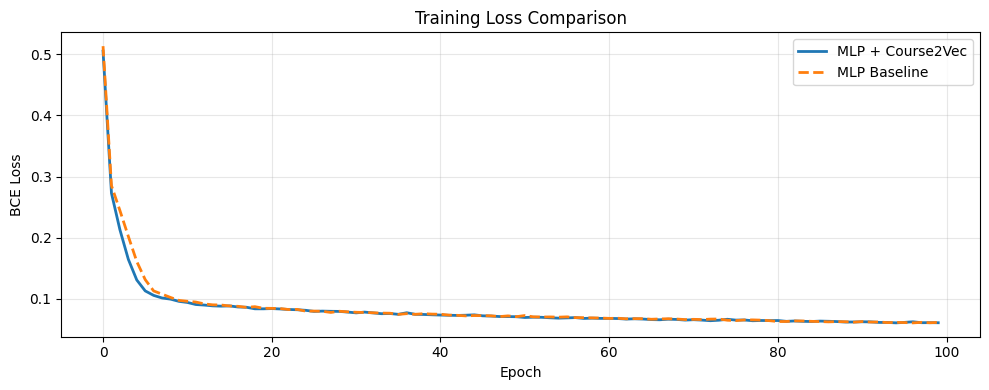

In [10]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(hist_enhanced["train_loss"], label="MLP + Course2Vec", linewidth=2)
ax.plot(hist_baseline["train_loss"], label="MLP Baseline", linewidth=2, linestyle="--")
ax.set_title("Training Loss Comparison")
ax.set_xlabel("Epoch")
ax.set_ylabel("BCE Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Evaluation

In [ ]:
model_enhanced.eval()
model_baseline.eval()

with torch.no_grad():
    pred_enhanced = model_enhanced(torch.FloatTensor(X_test)).numpy()
    pred_baseline = model_baseline(torch.FloatTensor(X_test_orig)).numpy()


def aggregate_predictions(
    pred_probs: np.ndarray,
    meta: list,
    y_actual: np.ndarray,
) -> tuple:
    """Aggregate student-level predictions to course-level per term."""
    student_agg = defaultdict(lambda: np.zeros(NUM_COURSES))
    actual_agg = defaultdict(lambda: np.zeros(NUM_COURSES))

    for i, (year, term, sid) in enumerate(meta):
        term_key = f"{year}-{term:02d}"
        student_agg[term_key] += pred_probs[i]
        actual_agg[term_key] += y_actual[i]

    terms = sorted(student_agg.keys())
    predictions = np.array([student_agg[t] for t in terms])
    actuals = np.array([actual_agg[t] for t in terms])
    return predictions, actuals, terms


pred_enh_agg, actuals_agg, terms = aggregate_predictions(pred_enhanced, meta_test, y_test)
pred_base_agg, _, _ = aggregate_predictions(pred_baseline, meta_test, y_test)

df_macro = create_macro_dataset(university_data, course_ids)
naive_model = NaiveModel(lag=2)
naive_model.fit(df_macro)
naive_preds = naive_model.predict(terms)

mae_enhanced = compute_mae(actuals_agg, pred_enh_agg)
mae_baseline = compute_mae(actuals_agg, pred_base_agg)
mae_naive = compute_mae(actuals_agg, naive_preds)

print(f"{'Model':<30s} MAE (students/course)")
print(f"{'---'*20}")
print(f"{'Naive (lag=2)':<30s} {mae_naive:.2f}")
print(f"{'MLP Baseline (no embeddings)':<30s} {mae_baseline:.2f}")
print(f"{'MLP + Course2Vec':<30s} {mae_enhanced:.2f}")

improvement = (mae_naive - mae_enhanced) / mae_naive * 100
print(f"\nCourse2Vec MLP vs Naive: {improvement:+.1f}%")

In [ ]:
course_labels_dict = {i: cid for i, cid in enumerate(course_ids)}

df_enh = per_course_mae(actuals_agg, pred_enh_agg, course_labels_dict)
df_base = per_course_mae(actuals_agg, pred_base_agg, course_labels_dict)

df_enh_sorted = df_enh.sort_values("MAE", ascending=False)
print("Course2Vec MLP -- Top 15 courses by MAE:")
print(df_enh_sorted.head(15).to_string(index=False))

In [ ]:
models = {
    "Naive": naive_preds,
    "MLP Baseline": pred_base_agg,
    "MLP + Course2Vec": pred_enh_agg,
}

term_idx = 0
term_name = terms[term_idx]

fig, ax = plt.subplots(figsize=(16, 6))
width = 0.2

# Only show courses with activity
active = np.where((actuals_agg[term_idx] > 0) | (pred_enh_agg[term_idx] > 1))[0]
active_labels_plot = [labels.get(i, f"C{i}")[:15] for i in active]

ax.bar(
    np.arange(len(active)) - 1.5 * width,
    actuals_agg[term_idx, active],
    width, label="Actual", color="black", alpha=0.8,
)
for j, (mname, mpred) in enumerate(models.items()):
    ax.bar(
        np.arange(len(active)) + (j - 0.5) * width,
        mpred[term_idx, active],
        width, label=mname, alpha=0.7,
    )

ax.set_xticks(range(len(active)))
ax.set_xticklabels(active_labels_plot, rotation=90, fontsize=7)
ax.set_title(f"Forecast Comparison -- Term {term_name}")
ax.set_ylabel("Enrollment Count")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## Forecast Heatmap

Actual vs predicted enrollment counts per course per test term for **MLP + Course2Vec**.
Each pair of columns shows Actual (left) and Predicted (right). Courses sorted by total activity.

In [ ]:
pred_rounded = np.round(pred_enh_agg).astype(int)
actuals_rounded = np.round(actuals_agg).astype(int)

records = []
for i, term in enumerate(terms):
    for c_idx in range(NUM_COURSES):
        a, p = actuals_rounded[i, c_idx], pred_rounded[i, c_idx]
        if a == 0 and p == 0:
            continue
        cname = labels.get(c_idx, f'ID_{c_idx}')
        records.append({'Course': cname, 'Time': term, 'Type': 'Actual', 'Count': a})
        records.append({'Course': cname, 'Time': term, 'Type': 'Predicted', 'Count': p})

df_heat = pd.DataFrame(records)
if not df_heat.empty:
    matrix = df_heat.groupby(['Course', 'Time', 'Type'])['Count'].sum().unstack(level=[1, 2], fill_value=0)
    matrix['Total'] = matrix.sum(axis=1)
    matrix = matrix.sort_values('Total', ascending=False).drop(columns=['Total'])

    plt.figure(figsize=(14, max(10, len(matrix) * 0.3)))
    sns.heatmap(matrix, annot=True, fmt='d', cmap='YlGnBu', mask=matrix == 0,
                linewidths=0.1, linecolor='white')
    plt.title('MLP + Course2Vec: Actual vs Predicted Enrollment per Course per Term')
    plt.tight_layout()
    plt.show()

## 9. Discussion

Course embeddings learned from enrollment patterns capture real curriculum structure, and
adding them as features improves enrollment prediction.

The t-SNE projection and nearest-neighbour analysis confirm the embedding space reflects
the curriculum. Courses from the same semester cluster together, which is expected given
co-enrollment is the training signal. More interesting are the cross-semester similarities:
optional and late-curriculum courses (Anglès Empresarial, Recursos Energètics, Interfícies
d'Usuari) cluster together because a similar subset of graduating students takes them.

The embedding-enhanced MLP achieves MAE 1.78, above the baseline MLP at 1.94 and well above
the naive predictor at 4.18. The gain comes at no extra data cost: embedding features are
derived from the same enrollment records.

Problms: the Word2Vec corpus is small (505 students, ~3,000 sentences), embedding dimension
was not tuned, and the embeddings are frozen during MLP training. An
end-to-end learnable embedding layer added to the Micro LSTM would be a the following extension.

In [ ]:
metrics = {
    "MAE_enhanced": float(mae_enhanced),
    "MAE_baseline": float(mae_baseline),
    "MAE_naive": float(mae_naive),
}
meta = build_experiment_metadata(
    "course2vec_mlp", "embedding_enhanced",
    {
        "embedding_dim": EMBEDDING_DIM, "window": 5, "sg": 1, "epochs_w2v": 50,
        "hidden_dim": 128, "epochs_mlp": 100, "batch_size": 64,
    },
    RANDOM_SEED, len(X_train), len(X_test), f"year >= {SPLIT_YEAR}",
)
json_path, csv_path = export_results("course2vec_mlp", metrics, df_enh, meta)
print(f"Saved: {json_path}")
print(f"        {csv_path}")

Saved: /Users/anassanhari/EPSEM/TFM/educast/results/course2vec_mlp_20260510_080359.json
        /Users/anassanhari/EPSEM/TFM/educast/results/course2vec_mlp_20260510_080359_per_course.csv
